In [28]:
import json
import pandas as pd
import ast
from transformers import pipeline
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_json('data/annotations/proficiency_demonstration_val.json')
df.head()

,ds,annotations
0,20231211_15:13:34,"{'task_id': 7002, 'task_name': 'Los_Andes_FPC1..."
1,20231211_15:13:34,"{'task_id': 9002, 'task_name': 'Performing the..."
2,20231211_15:13:34,"{'task_id': 9002, 'task_name': 'Performing the..."
3,20231211_15:13:34,"{'task_id': 5012, 'task_name': 'Playing Piano ..."
4,20231211_15:13:34,"{'task_id': 6003, 'task_name': 'Basketball Dri..."


In [3]:
good_executions = [
    item
    for ge_entry in df['annotations'].iloc[0]['good_executions']
    for item in ast.literal_eval(ge_entry['list'])
]
tips_for_improvement = [
    item
    for tfi_entry in df['annotations'].iloc[0]['tips_for_improvement']
    for item in ast.literal_eval(tfi_entry['list'])
]

In [4]:
good_executions[:10]

["I like all the prep that's going into it.",
 "She is not only looking at the hold, she's also brushing the hold.",
 'this climber is showing that she has an understanding of what that means by brushing the hold and she wants to have better grip with these handholds',
 'This climber starts by brushing the holds.',
 'climber is brushing the holds',
 'climber doing good due diligence here and making sure they understand the boulder',
 'making sure that the holds on the wall are clean',
 'climber is reading her route',
 'chalking up her hands',
 'She is wiping the chalk from her hands']

In [5]:
tips_for_improvement[:10]

["Sometimes there's an excess of chalk built up by brushing the holds, kind of remove that layer of built-up chalk.",
 "By using this long brush, you'll be able to kind of get the holds up high that maybe are flat or slopier, pinchier, whatever she deems is maybe being tougher.",
 "By brushing them, she'll kind of get an extra edge by, you know, removing that layer of chalk and getting back to that, the friction of the hold, which should be easier to grip than chalky hands on top of a chalky hold.",
 'An extended brush to get those higher holds.',
 'Tends to be a lot of chalk buildup, skin oil buildup as the holds get dirty.',
 "So it's really good to give him a nice brush, sort of clean them while you're in the midst of your attempts.",
 "I also made a mistake and didn't watch the full recording before annotating. So my bad, I'll watch it and go through it. Just got excited.",
 'Make sure to take a few seconds to look at the route and memorize the sequence.',
 'Shake out your hands to

In [ ]:
classifier = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 24012.31it/s]


[{'label': 'POSITIVE', 'score': 0.9952020645141602}, {'label': 'POSITIVE', 'score': 0.9824017882347107}, {'label': 'NEGATIVE', 'score': 0.9035786390304565}, {'label': 'NEGATIVE', 'score': 0.6705577969551086}, {'label': 'NEGATIVE', 'score': 0.898501455783844}, {'label': 'POSITIVE', 'score': 0.9997264742851257}, {'label': 'POSITIVE', 'score': 0.9974594712257385}, {'label': 'POSITIVE', 'score': 0.9818031787872314}, {'label': 'NEGATIVE', 'score': 0.9313886761665344}, {'label': 'NEGATIVE', 'score': 0.9955955147743225}, {'label': 'NEGATIVE', 'score': 0.9992144107818604}, {'label': 'POSITIVE', 'score': 0.9998613595962524}, {'label': 'NEGATIVE', 'score': 0.8589794039726257}, {'label': 'NEGATIVE', 'score': 0.9982659220695496}, {'label': 'NEGATIVE', 'score': 0.8148475885391235}, {'label': 'POSITIVE', 'score': 0.9944630265235901}, {'label': 'POSITIVE', 'score': 0.8357150554656982}, {'label': 'POSITIVE', 'score': 0.9986258745193481}, {'label': 'NEGATIVE', 'score': 0.9938554167747498}, {'label': 'P

In [14]:
ge_result = classifier(good_executions)
ge_result[:10]

[{'label': 'POSITIVE', 'score': 0.9952020645141602},
 {'label': 'POSITIVE', 'score': 0.9824017882347107},
 {'label': 'NEGATIVE', 'score': 0.9035786390304565},
 {'label': 'NEGATIVE', 'score': 0.6705577969551086},
 {'label': 'NEGATIVE', 'score': 0.898501455783844},
 {'label': 'POSITIVE', 'score': 0.9997264742851257},
 {'label': 'POSITIVE', 'score': 0.9974594712257385},
 {'label': 'POSITIVE', 'score': 0.9818031787872314},
 {'label': 'NEGATIVE', 'score': 0.9313886761665344},
 {'label': 'NEGATIVE', 'score': 0.9955955147743225}]

In [15]:
tfi_result = classifier(tips_for_improvement)
tfi_result[:10]

[{'label': 'NEGATIVE', 'score': 0.9992088675498962},
 {'label': 'NEGATIVE', 'score': 0.9840187430381775},
 {'label': 'NEGATIVE', 'score': 0.9901800155639648},
 {'label': 'POSITIVE', 'score': 0.9756767153739929},
 {'label': 'NEGATIVE', 'score': 0.998297393321991},
 {'label': 'POSITIVE', 'score': 0.9997161030769348},
 {'label': 'POSITIVE', 'score': 0.5780659914016724},
 {'label': 'NEGATIVE', 'score': 0.9943200349807739},
 {'label': 'POSITIVE', 'score': 0.9936774373054504},
 {'label': 'NEGATIVE', 'score': 0.9892282485961914}]

In [29]:
ge_labels = np.array([1 if item['label'] == 'POSITIVE' else -1 for item in ge_result])
ge_scores = np.array([item['score'] for item in ge_result])
ge_labels[:10], ge_scores[:10]

(array([ 1,  1, -1, -1, -1,  1,  1,  1, -1, -1]),
 array([0.99520206, 0.98240179, 0.90357864, 0.6705578 , 0.89850146,
        0.99972647, 0.99745947, 0.98180318, 0.93138868, 0.99559551]))

In [30]:
tfi_labels = np.array([1 if item['label'] == 'POSITIVE' else -1 for item in tfi_result])
tfi_scores = np.array([item['score'] for item in tfi_result])
tfi_labels[:10], tfi_scores[:10]

(array([-1, -1, -1,  1, -1,  1,  1, -1,  1, -1]),
 array([0.99920887, 0.98401874, 0.99018002, 0.97567672, 0.99829739,
        0.9997161 , 0.57806599, 0.99432003, 0.99367744, 0.98922825]))

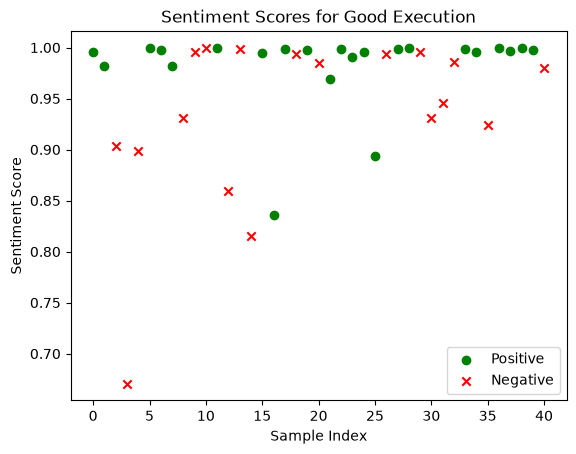

In [37]:
ge_x = np.arange(len(ge_scores))  # or your actual x-axis values
ge_pos_mask = ge_labels == 1
ge_neg_mask = ge_labels == -1

plt.scatter(ge_x[ge_pos_mask], ge_scores[ge_pos_mask], c='green', marker='o', label='Positive')
plt.scatter(ge_x[ge_neg_mask], ge_scores[ge_neg_mask], c='red', marker='x', label='Negative')

plt.title('Sentiment Scores for Good Execution')
plt.ylabel('Sentiment Score')
plt.xlabel('Sample Index')
plt.legend()

plt.savefig('figures/good_execution_sentiment.png')
plt.show()

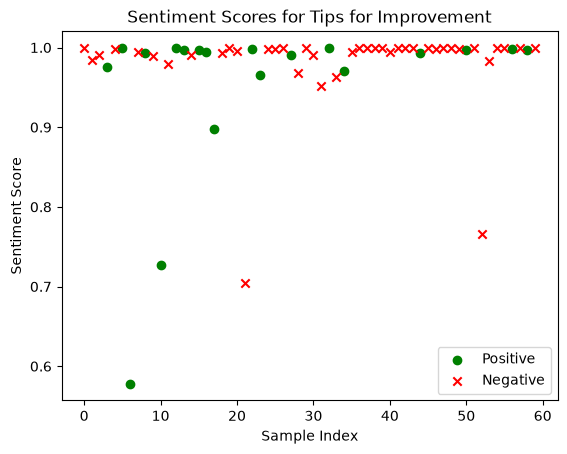

In [38]:
tfi_x = np.arange(len(tfi_scores))  # or your actual x-axis values
tfi_pos_mask = tfi_labels == 1
tfi_neg_mask = tfi_labels == -1

plt.scatter(tfi_x[tfi_pos_mask], tfi_scores[tfi_pos_mask], c='green', marker='o', label='Positive')
plt.scatter(tfi_x[tfi_neg_mask], tfi_scores[tfi_neg_mask], c='red', marker='x', label='Negative')


plt.title('Sentiment Scores for Tips for Improvement')
plt.ylabel('Sentiment Score')
plt.xlabel('Sample Index')
plt.legend()

plt.savefig('figures/tips_for_improvement_sentiment.png')
plt.show()